#Examen1

## Ejercicio 1

In [ ]:
try:
  import CompStats
except ImportError:
  !pip install git+https://github.com/INGEOTEC/CompStats@develop

In [186]:
from tqdm import tqdm
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from CompStats.metrics import f1_score, accuracy_score
from CompStats import measurements
from sklearn.metrics import recall_score

In [112]:
bioresponse1 = fetch_openml(data_id=4134)

In [113]:
y1 = bioresponse1.target.to_numpy()
D1 = bioresponse1.data.to_numpy()

In [114]:
Xtrain, Xtest, ytrain, ytest = train_test_split(D1, np.array(y1),random_state=17)

In [115]:
# tamanio
Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape

((2813, 1776), (938, 1776), (2813,), (938,))

In [116]:
naive1 = GaussianNB().fit(Xtrain, ytrain)

In [117]:
lda1 = LDA().fit(Xtrain, ytrain)

In [118]:
qda1 = QDA().fit(Xtrain, ytrain)

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [119]:
hy_naive1 = naive1.predict(Xtest)

In [120]:
hy_lda1 = lda1.predict(Xtest)

In [121]:
hy_qda1 = qda1.predict(Xtest)

#########################

In [ ]:
accuracy_score(ytest, hy_naive1)

100%|██████████| 1/1 [00:00<00:00,  2.67it/s]


<Perf(score_func=accuracy_score, statistic=0.7540, se=0.0337)>

In [ ]:
accuracy_score(ytest, hy_lda1)

100%|██████████| 1/1 [00:00<00:00,  2.61it/s]


<Perf(score_func=accuracy_score, statistic=0.7914, se=0.0290)>

In [ ]:
accuracy_score(ytest, hy_qda1)

100%|██████████| 1/1 [00:00<00:00,  2.61it/s]


<Perf(score_func=accuracy_score, statistic=0.7433, se=0.0311)>

In [ ]:
acc = accuracy_score(ytest)
acc(hy_naive1, name='Gaussian')
acc(hy_lda1, name='LDA')
acc(hy_qda1, name='QDA')

100%|██████████| 3/3 [00:01<00:00,  2.56it/s]


<Perf(score_func=accuracy_score)>
Statistic with its standard error (se)
statistic (se)
0.7914 (0.0285) <= LDA
0.7540 (0.0311) <= Gaussian
0.7433 (0.0317) <= QDA

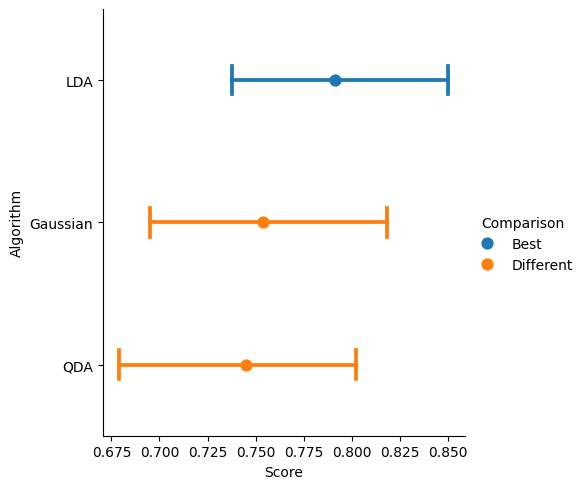

In [ ]:
acc.plot()

##### Macro-f1

In [ ]:
score = f1_score(ytest, hy_naive1, average='macro')
score

100%|██████████| 1/1 [00:02<00:00,  2.15s/it]


<Perf(score_func=f1_score, statistic=0.5022, se=0.0359)>

In [122]:
score = f1_score(ytest, average='macro')
score(hy_naive1, name='Gaussian')
score(hy_lda1, name='LDA')
score(hy_qda1, name='QDA')

100%|██████████| 3/3 [00:09<00:00,  3.01s/it]


<Perf(score_func=f1_score)>
Statistic with its standard error (se)
statistic (se)
0.7013 (0.0152) <= LDA
0.5247 (0.0162) <= Gaussian
0.4449 (0.0156) <= QDA

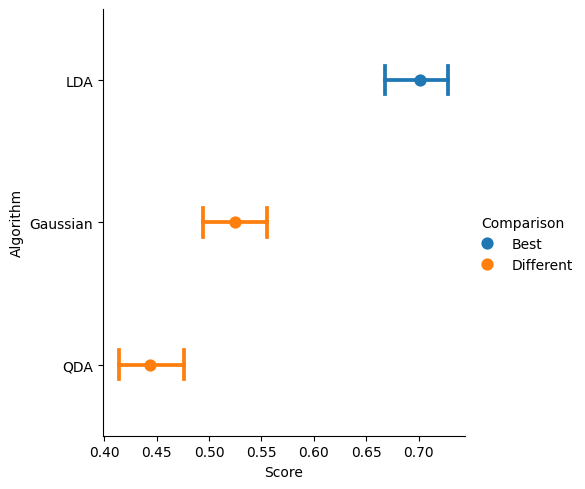

In [123]:
score.plot()

## Ejercicio 2

In [128]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from sklearn import datasets
import seaborn as sns
import pandas as pd
import numpy as np
import umap

In [129]:
problem = fetch_openml(data_id=1489)
print(problem.DESCR)

**Author**: Dominique Van Cappel, THOMSON-SINTRA  
**Source**: [KEEL](http://sci2s.ugr.es/keel/dataset.php?cod=105#sub2), [ELENA](https://www.elen.ucl.ac.be/neural-nets/Research/Projects/ELENA/databases/REAL/phoneme/) - 1993  
**Please cite**: None  

The aim of this dataset is to distinguish between nasal (class 0) and oral sounds (class 1). Five different attributes were chosen to characterize each vowel: they are the amplitudes of the five first harmonics AHi, normalised by the total energy Ene (integrated on all the frequencies): AHi/Ene. The phonemes are transcribed as follows: sh as in she, dcl as in dark, iy as the vowel in she, aa as the vowel in dark, and ao as the first vowel in water.  

### Source

The current dataset was formatted by the KEEL repository, but originally hosted by the [ELENA Project](https://www.elen.ucl.ac.be/neural-nets/Research/Projects/ELENA/elena.htm#stuff). The dataset originates from the European ESPRIT 5516 project: ROARS. The aim of this project was

In [132]:
# definimos UMAP
emb = umap.UMAP(metric="euclidean", n_neighbors=8, n_components=2).fit_transform(problem.data)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


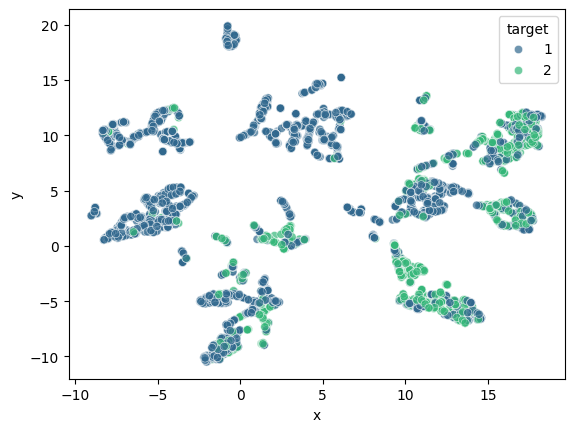

In [136]:
df = pd.DataFrame(data=emb, columns=["x", "y"])
df["target"] = problem.target
sns.scatterplot(x="x", y="y",
    hue="target", palette='viridis',
    alpha=0.7, data=df)
plt.show()

In [137]:
from IPython.display import Markdown
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

In [138]:
problem.data

,V1,V2,V3,V4,V5
0,0.489927,-0.451528,-1.047990,-0.598693,-0.020418
1,-0.641265,0.109245,0.292130,-0.916804,0.240223
2,0.870593,-0.459862,0.578159,0.806634,0.835248
3,-0.628439,-0.316284,1.934295,-1.427099,-0.136583
4,-0.596399,0.015938,2.043206,-1.688448,-0.948127
...,...,...,...,...,...
5399,-0.658318,1.331760,-0.081621,1.794253,-1.082181
5400,-0.044375,-0.010512,0.030989,-0.019379,1.281061
5401,0.246882,-0.793228,1.190101,1.423194,-1.303036
5402,-0.778907,-0.383111,1.727029,-1.432389,-1.208085


In [159]:
df_vowels = problem.frame

In [160]:
# checamos que no haya datos faltantes
df_vowels.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
Class,0


In [161]:
df_pca = df_vowels.copy()

In [162]:
# estandarizamos
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_pca)

In [164]:
# hacemos el PCA
model = PCA(n_components=2)
principal_components = model.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Añadir la columna de supervivencia para la visualización
pca_df['class'] = df_vowels['Class']

pca_df.head(5)

,PC1,PC2,class
0,-1.133073,-0.680053,1
1,-0.339867,0.752257,1
2,0.143757,-1.002799,1
3,0.303823,0.899019,1
4,0.009948,1.248809,1


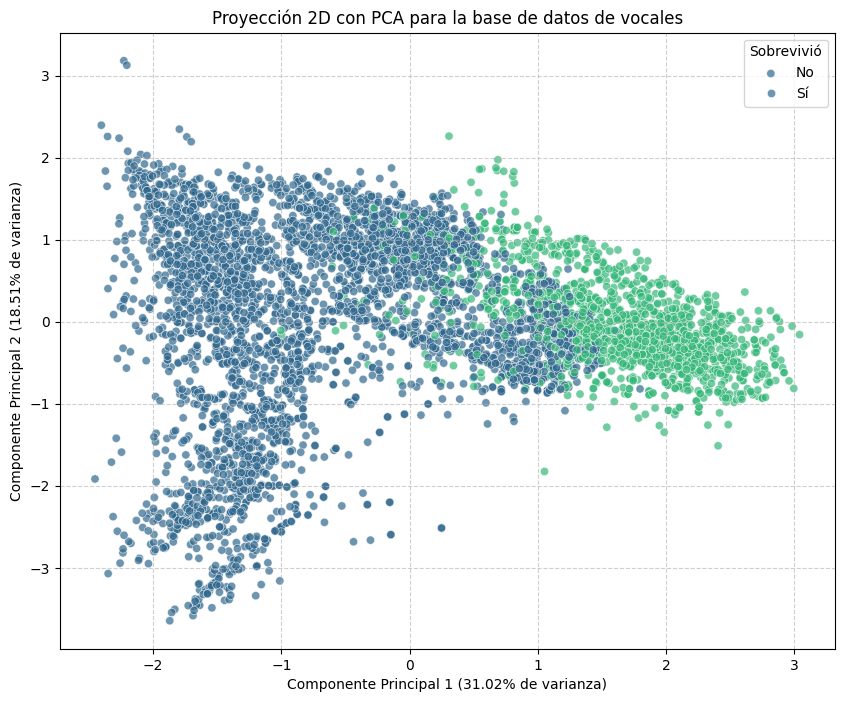

In [168]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='class', # Colorea los puntos según si sobrevivieron o no
    palette='viridis', # Esquema de colores
    alpha=0.7 # Transparencia
)
plt.title('Proyección 2D con PCA para la base de datos de vocales')
plt.xlabel(f'Componente Principal 1 ({model.explained_variance_ratio_[0]*100:.2f}% de varianza)')
plt.ylabel(f'Componente Principal 2 ({model.explained_variance_ratio_[1]*100:.2f}% de varianza)')
plt.legend(title='Sobrevivió', labels=['No', 'Sí'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [171]:
dataset = fetch_openml(data_id=1489, as_frame=True)
X = dataset.data
y = dataset.target

In [174]:
X_select = X.iloc[:, [3, 0]]  # Columna 3 (x4) y columna 0 (x1)
X_select

,V4,V1
0,-0.598693,0.489927
1,-0.916804,-0.641265
2,0.806634,0.870593
3,-1.427099,-0.628439
4,-1.688448,-0.596399
...,...,...
5399,1.794253,-0.658318
5400,-0.019379,-0.044375
5401,1.423194,0.246882
5402,-1.432389,-0.778907


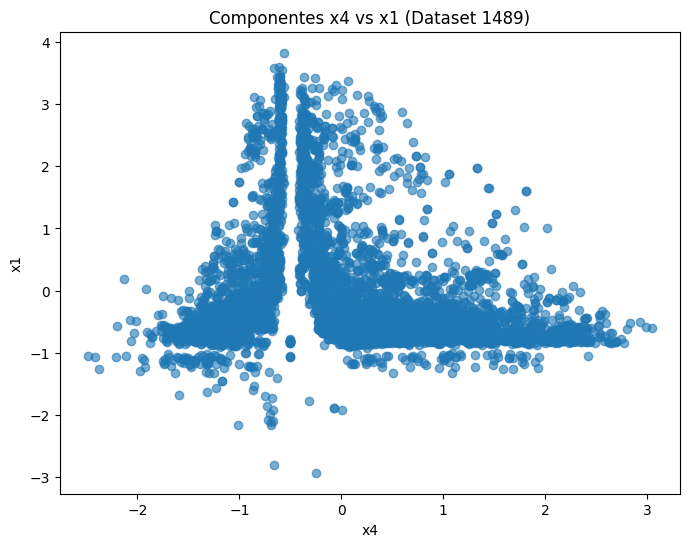

In [179]:
plt.figure(figsize=(8, 6))
plt.scatter(X_select.iloc[:, 0], X_select.iloc[:, 1], alpha=0.6)
plt.xlabel('x4')
plt.ylabel('x1')
plt.title('Componentes x4 vs x1 (Dataset 1489)')
plt.show()

## Ejercicio 4

In [180]:
bioresponse = fetch_openml(data_id=4134)

In [181]:
y = bioresponse.target.to_numpy()
D = bioresponse.data.to_numpy()

In [184]:
Xtrain, Xtest, ytrain, ytest = train_test_split(D, np.array(y),random_state=17)

In [185]:
Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape

((2813, 1776), (938, 1776), (2813,), (938,))

In [189]:
svm = LinearSVC().fit(Xtrain, ytrain) # maquina de soporte vectorial

In [190]:
reg_log = LogisticRegression().fit(Xtrain, ytrain) # regresion logistica

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [198]:
# normalizadas
svm_norm = make_pipeline(Normalizer(), LinearSVC()).fit(Xtrain, ytrain)
reg_log_norm = make_pipeline(Normalizer(), LogisticRegression()).fit(Xtrain, ytrain)

In [200]:
score1 = f1_score(ytest, average='macro')
score1(svm.predict(Xtest), name='SVM')
score1(reg_log.predict(Xtest), name='Reg Log.')
score1(svm_norm.predict(Xtest), name='SVM Norm')
score1(reg_log_norm.predict(Xtest), name='Reg. Log. Norm')

100%|██████████| 4/4 [00:24<00:00,  6.01s/it]


<Perf(score_func=f1_score)>
Statistic with its standard error (se)
statistic (se)
0.7498 (0.0143) <= SVM Norm
0.7454 (0.0140) <= Reg. Log. Norm
0.7324 (0.0146) <= Reg Log.
0.7204 (0.0148) <= SVM

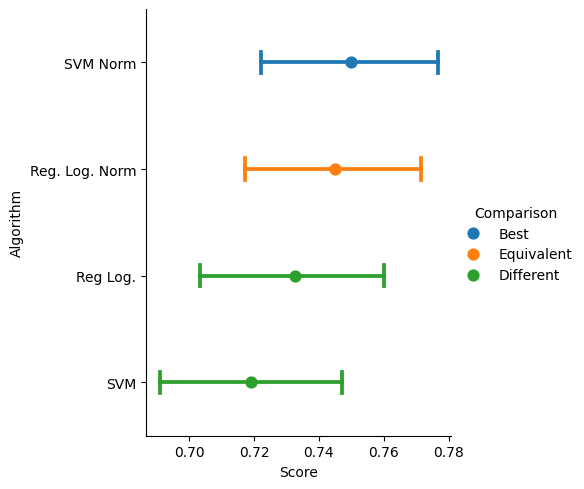

In [202]:
score1.plot()